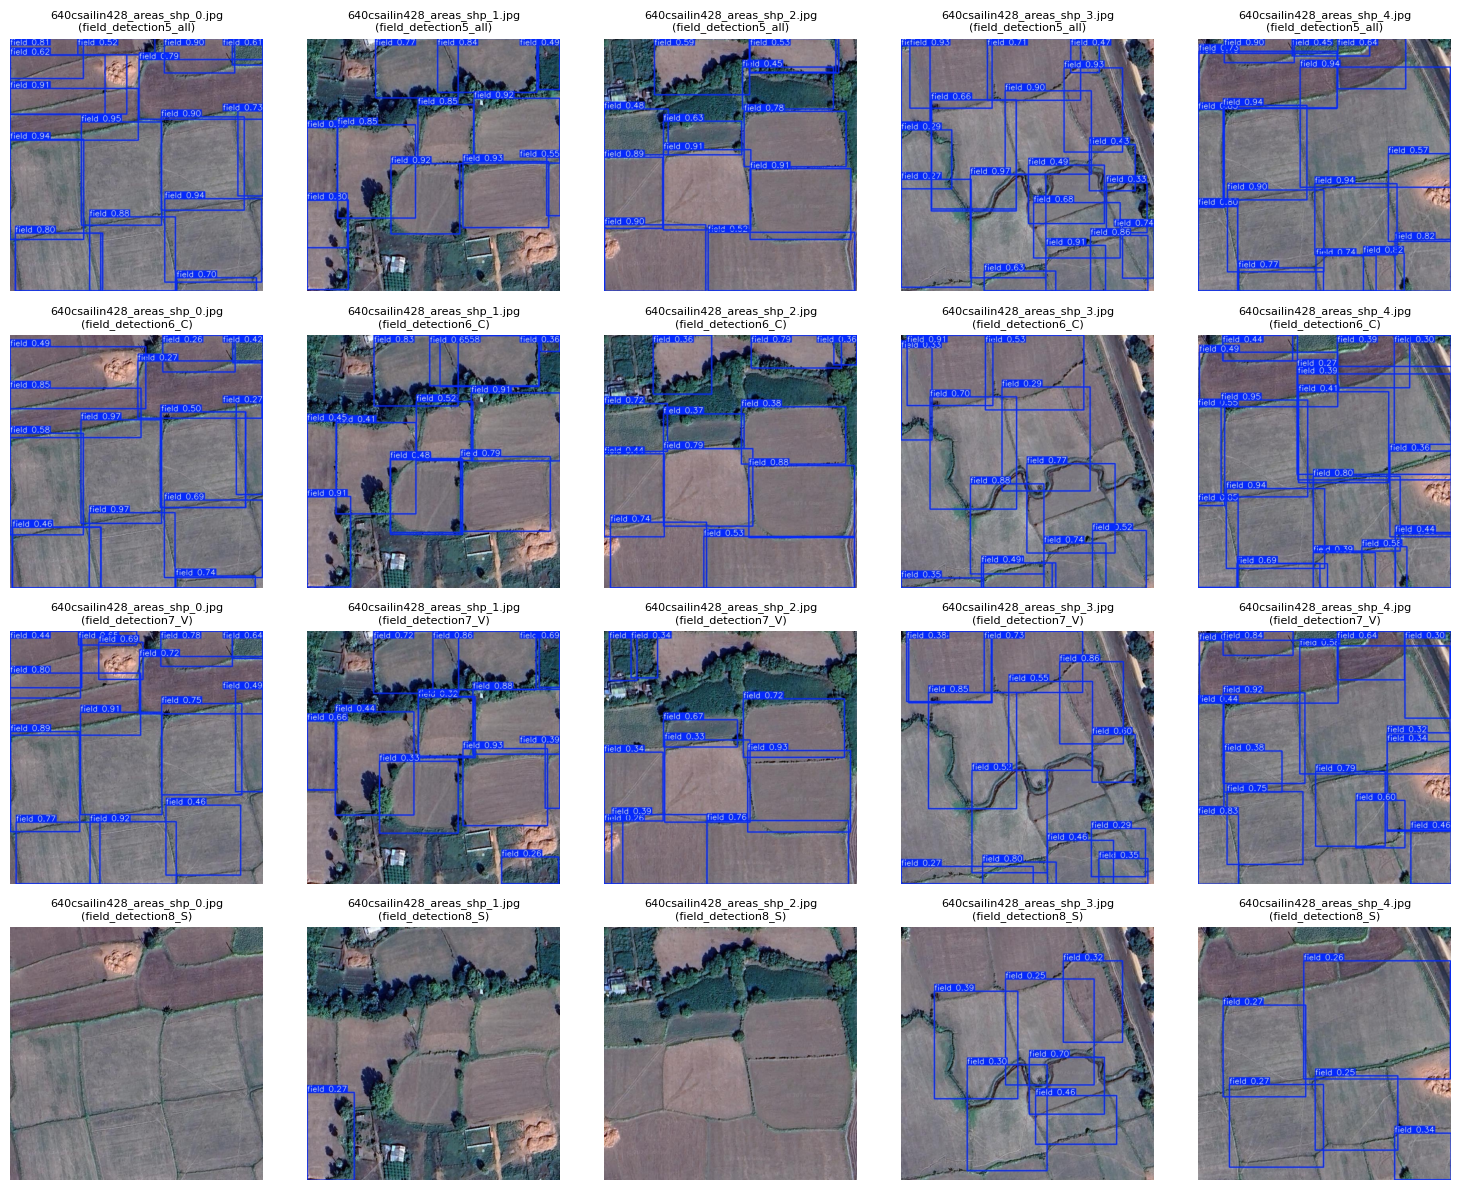

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Base directory
base_dir = r"D:/SIG/Yolo/predict"
base_folders = ["field_detection5_all", "field_detection6_C", "field_detection7_V", "field_detection8_S"]
# base_folders = ["field_detection5_all", "field_detection_m"]

# Function to read images from a folder
def read_images_from_folder(folder_path, max_images=5):
    images = []
    filenames = []
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):  # Add other formats if necessary
            file_path = os.path.join(folder_path, file_name)
            images.append(Image.open(file_path))
            filenames.append(file_name)
            if len(images) == max_images:  # Limit the number of images to display
                break
    return images, filenames

# Plot comparison
def plot_comparisons(base_dir, base_folders, max_images=5):
    fig, axs = plt.subplots(len(base_folders), max_images, figsize=(15, len(base_folders) * 3))
    
    for i, folder in enumerate(base_folders):
        folder_path = os.path.join(base_dir, folder)
        images, filenames = read_images_from_folder(folder_path, max_images)
        
        for j in range(max_images):
            ax = axs[i, j] if len(base_folders) > 1 else axs[j]
            if j < len(images):
                ax.imshow(images[j])
                ax.axis("off")
                ax.set_title(f"{filenames[j]}\n({folder})", fontsize=8)
            else:
                ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_comparisons(base_dir, base_folders)
